In [1]:
import pandas as pd
import numpy as np

from generator import DatasetGenerator
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


In [2]:

df = pd.read_parquet("tracks/row/track001.parquet")

df.head()

,frame,timestamp,marker_id,track_id,object_class,x,y
0,138,1.784354e+09,52,0,STATIC,7.562395,32.959998
1,575,1.784354e+09,52,0,STATIC,2.250063,17.294985
2,579,1.784354e+09,52,0,STATIC,2.299537,17.254097
3,582,1.784354e+09,52,0,STATIC,2.279854,17.248756
4,587,1.784354e+09,52,0,STATIC,2.298563,17.229873


In [3]:

df.describe()

,frame,timestamp,marker_id,track_id,x,y
count,439.000000,4.390000e+02,439.0,439.0,439.000000,439.000000
mean,1059.945330,1.784354e+09,52.0,0.0,1.452225,17.339464
std,285.436255,9.591240e+00,0.0,0.0,0.669411,0.754289
min,138.000000,1.784354e+09,52.0,0.0,0.838231,17.087806
25%,804.500000,1.784354e+09,52.0,0.0,0.983013,17.210220
50%,1070.000000,1.784354e+09,52.0,0.0,1.000576,17.318864
75%,1334.000000,1.784354e+09,52.0,0.0,2.130288,17.385174
max,1515.000000,1.784354e+09,52.0,0.0,7.562395,32.959998


In [4]:

generator = DatasetGenerator(input_window=20, output_window=10)
X, Y = generator.generate(df)


print(X.shape)

print(Y.shape)

(410, 20, 2)
(410, 10, 2)


In [5]:


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [6]:


class TrajectoryLSTM(nn.Module):
    def __init__(
        self,
        input_size=2,
        hidden_size=64,
        num_layers=2,
        output_window=10,
    ):
        super().__init__()
        self.output_window = output_window
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, output_window * input_size),
        )

    def forward(self, x):
        """
        x: [batch, 20, 2]
        """
        out, (h, c) = self.lstm(x)
        # последнее скрытое состояние
        out = out[:, -1]
        out = self.head(out)
        out = out.view(
            -1,
            self.output_window,
            2
        )

        return out

In [7]:

model = TrajectoryLSTM()

x = torch.randn(32, 20, 2)

y = model(x)

print(y.shape)

torch.Size([32, 10, 2])


In [8]:
# data = np.load("dataset.npz")

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

dataset = TensorDataset(X, Y)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = TrajectoryLSTM().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [10]:
epochs = 500

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}: "
        f"{total_loss / len(loader):.6f}"
    )

Epoch 1: 146.518896
Epoch 2: 120.617755
Epoch 3: 66.524730
Epoch 4: 15.399875
Epoch 5: 1.605034
Epoch 6: 1.092200
Epoch 7: 0.269689
Epoch 8: 0.241597
Epoch 9: 0.180499
Epoch 10: 0.178919
Epoch 11: 0.174658
Epoch 12: 0.179471
Epoch 13: 0.181172
Epoch 14: 0.189515
Epoch 15: 0.184746
Epoch 16: 0.180676
Epoch 17: 0.181319
Epoch 18: 0.185907
Epoch 19: 0.180233
Epoch 20: 0.178477
Epoch 21: 0.176275
Epoch 22: 0.176302
Epoch 23: 0.175353
Epoch 24: 0.179723
Epoch 25: 0.174932
Epoch 26: 0.179093
Epoch 27: 0.187429
Epoch 28: 0.181600
Epoch 29: 0.178644
Epoch 30: 0.179593
Epoch 31: 0.177931
Epoch 32: 0.178764
Epoch 33: 0.182055
Epoch 34: 0.184802
Epoch 35: 0.183101
Epoch 36: 0.176694
Epoch 37: 0.177094
Epoch 38: 0.173761
Epoch 39: 0.183138
Epoch 40: 0.192635
Epoch 41: 0.186346
Epoch 42: 0.177013
Epoch 43: 0.174632
Epoch 44: 0.174487
Epoch 45: 0.174873
Epoch 46: 0.176591
Epoch 47: 0.183321
Epoch 48: 0.174715
Epoch 49: 0.175559
Epoch 50: 0.180080
Epoch 51: 0.181815
Epoch 52: 0.181592
Epoch 53: 0.178

In [11]:
model.eval()

with torch.no_grad():
    pred = model(X[:1].to(device))

prediction = pred.cpu().numpy()
ground_truth = Y[:1].numpy()
history = X[:1].numpy()

torch.Size([410, 20, 2])
torch.Size([410, 10, 2])


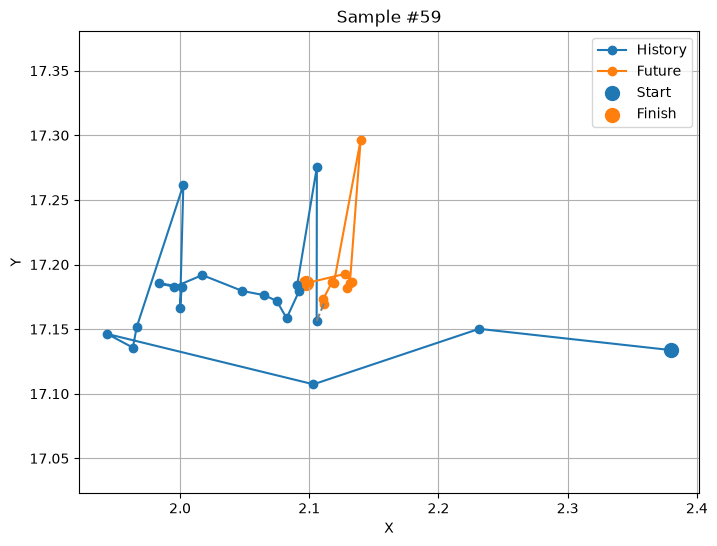

In [12]:
print(X.shape)
print(Y.shape)

# случайный пример
idx = np.random.randint(len(X))

history = X[idx]
future = Y[idx]

plt.figure(figsize=(8, 6))

# история
plt.plot(
    history[:, 0],
    history[:, 1],
    "-o",
    label="History",
)

# будущее
plt.plot(
    future[:, 0],
    future[:, 1],
    "-o",
    label="Future",
)

# соединяем историю и будущее
plt.plot(
    [history[-1, 0], future[0, 0]],
    [history[-1, 1], future[0, 1]],
    "--",
    color="gray"
)

plt.scatter(
    history[0, 0],
    history[0, 1],
    s=100,
    label="Start"
)

plt.scatter(
    future[-1, 0],
    future[-1, 1],
    s=100,
    label="Finish"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.title(f"Sample #{idx}")

plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

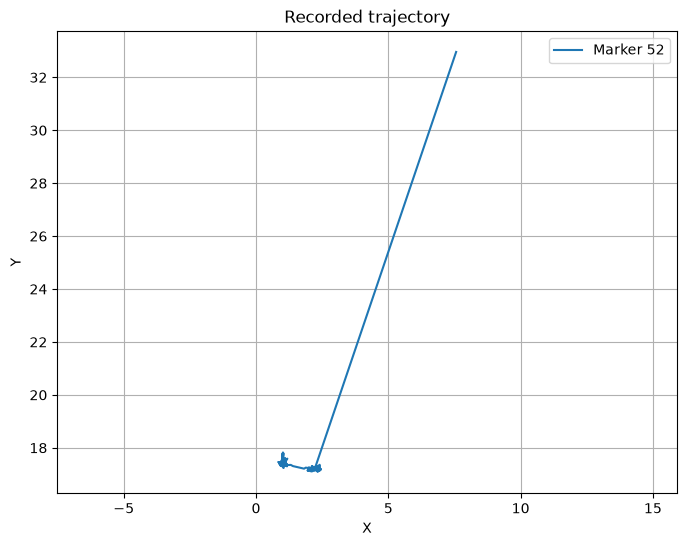

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

for marker_id, track in df.groupby("marker_id"):
    plt.plot(
        track["x"],
        track["y"],
        label=f"Marker {marker_id}"
    )

plt.title("Recorded trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [14]:
model.eval()

history = torch.tensor(
    X[idx:idx+1],
    dtype=torch.float32
).to(device)

with torch.no_grad():
    prediction = model(history)

history = history.cpu().numpy()[0]
prediction = prediction.cpu().numpy()[0]
future = Y[idx]

/var/folders/sl/b26qhmf14pzf37dy2nt9vy6r0000gn/T/ipykernel_69833/3722563553.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  history = torch.tensor(


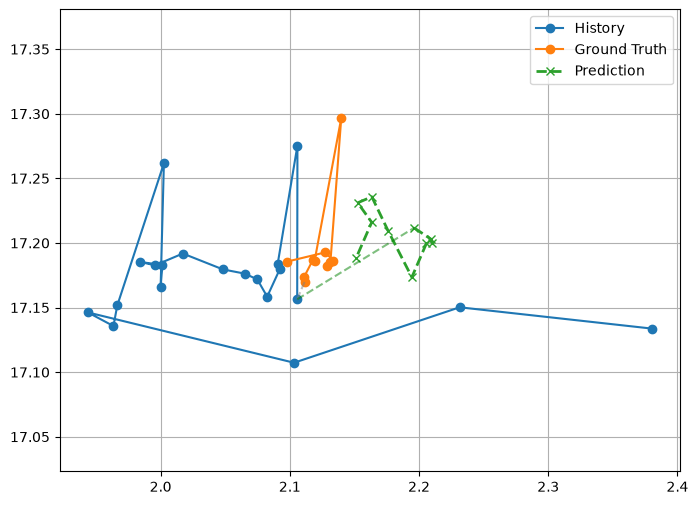

In [15]:
plt.figure(figsize=(8, 6))

# История
plt.plot(
    history[:, 0],
    history[:, 1],
    "-o",
    label="History"
)

# Реальное будущее
plt.plot(
    future[:, 0],
    future[:, 1],
    "-o",
    label="Ground Truth"
)

# Предсказание сети
plt.plot(
    prediction[:, 0],
    prediction[:, 1],
    "--x",
    linewidth=2,
    label="Prediction"
)

# Соединяем историю с будущим
plt.plot(
    [history[-1, 0], future[0, 0]],
    [history[-1, 1], future[0, 1]],
    "--",
    color="gray",
    alpha=0.5
)

# Соединяем историю с прогнозом
plt.plot(
    [history[-1, 0], prediction[0, 0]],
    [history[-1, 1], prediction[0, 1]],
    "--",
    color="green",
    alpha=0.5
)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()
